# Obesity Level Estimation


This project analyzes a dataset of **2,111 records** with **17 attributes** from Mexico, Peru, and Colombia.  
The target variable `NObesity` classifies individuals into 7 categories:  
*Insufficient Weight, Normal Weight, Overweight I, Overweight II, Obesity I, Obesity II, Obesity III.*

- **77%** of the data was synthetically generated using SMOTE.  
- **23%** was collected directly from users via a web platform.  

The goal is to perform **data analysis, visualization, and insights** on eating habits, physical activity, and health conditions to understand obesity risk patterns.


### 1. Data Loading and Initial Overview 
● Import the dataset using Pandas and provide an overview: 
○ Number of rows and columns 
○ Data types of each column 
○ Initial observations (e.g., head(), info(), describe()) 

In [4]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\layaj\OneDrive\Desktop\ObesityDataSet_raw_and_data_sinthetic.csv")

In [5]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Dataset Features

- **Gender** – Gender of the individual  
- **Age** – Age in years  
- **Height** – Height of the individual  
- **Weight** – Weight of the individual  
- **family_history_with_overweight** – Whether a family member has suffered from overweight  
- **FAVC** – Do you eat high caloric food frequently?  
- **FCVC** – Do you usually eat vegetables in your meals?  
- **NCP** – Number of main meals per day  
- **CAEC** – Do you eat food between meals?  
- **SMOKE** – Do you smoke?
- **CH2O** – How much water do you drink daily?  
- **SCC** – Do you monitor the calories you eat daily?  
- **FAF** – How often do you have physical activity?  
- **TUE** – Time spent using technological devices (cell phone, videogames, TV, computer, etc.)  
- **CALC** – How often do you drink alcohol?  
- **MTRANS** – Which transportation do you usually use?  
- **NObeyesdad** – Obesity level (target variable)  



### Legend for Encoded Columns

| Column | Meaning | Values / Encoding |
|--------|---------|-------------------|
| **Gender** | Biological sex | Male, Female |
| **family_history_with_overweight** | Family history of overweight/obesity | yes, no |
| **FAVC** | Frequent consumption of high-calorie food | yes, no |
| **FCVC** | Frequency of vegetable consumption | 1 = Rarely, 2 = Sometimes, 3 = Frequently, 4 = Always |
| **NCP** | Number of main meals per day | Integer (e.g., 1–4) |
| **CAEC** | Consumption of food between meals | no, Sometimes, Frequently, Always |
| **SMOKE** | Smoking habit | yes, no |
| **CH2O** | Daily water intake (liters) | 1 = <1L, 2 = 1–2L, 3 = >2L |
| **SCC** | Calorie consumption monitoring | yes, no |
| **FAF** | Physical activity frequency (hours per week) | 0 = None, 1 = 1–2 hrs/week, 2 = 2–4 hrs/week, 3 = >4 hrs/week |
| **TUE** | Time using technology devices (hours per day) | 0 = <2 hrs/day, 1 = 3–5 hrs/day, 2 = >5 hrs/day |
| **CALC** | Alcohol consumption | no, Sometimes, Frequently, Always |
| **MTRANS** | Mode of transportation | Automobile, Motorbike, Bike, Public Transportation, Walking |
| **NObeyesdad** | Obesity level (target variable) | Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III |


In [6]:
print("shape of the data set:",df.shape)

shape of the data set: (2111, 17)


In [7]:
print(df.dtypes)

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

### Initial Observations

- **Target column**: `NObeyesdad` (categorical variable indicating obesity levels).
- **Numerical features**: Age, Height, Weight, CH2O (water intake), FAF (physical activity frequency), etc.
- **Categorical features**: Gender, family history, transport mode, smoking, etc.
- **Potential derived feature**: BMI = Weight / (Height²).
- **Balance check**: Obesity categories appear diverse, but distribution needs to be checked for imbalance.
- **Data quality**: No obvious missing values from `info()`, but categorical encoding will be required.


### 2. Data Pre-processing 
● Perform all necessary cleaning steps such as: 
○ Handling missing values 
○ Removing duplicates 
○ Correcting data types 
○ Creating derived columns 
○ Filtering or aggregating data 

### 1.Handling missing values

In [9]:
# Check for missing values
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


####  Already checked: no missing values

### 2.Handling duplicates

In [10]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 24


In [11]:
# Show duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

     Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
98   Female  21.0    1.52    42.0                             no   no   3.0   
106  Female  25.0    1.57    55.0                             no  yes   2.0   
174    Male  21.0    1.62    70.0                             no  yes   2.0   
179    Male  21.0    1.62    70.0                             no  yes   2.0   
184    Male  21.0    1.62    70.0                             no  yes   2.0   
209  Female  22.0    1.69    65.0                            yes  yes   2.0   
309  Female  16.0    1.66    58.0                             no   no   2.0   
460  Female  18.0    1.62    55.0                            yes  yes   2.0   
467    Male  22.0    1.74    75.0                            yes  yes   3.0   
496    Male  18.0    1.72    53.0                            yes  yes   2.0   
527  Female  21.0    1.52    42.0                             no  yes   3.0   
659  Female  21.0    1.52    42.0                   

In [12]:
# Remove duplicates
df1 = df.drop_duplicates()

# Verify again
print("After removing duplicates:", df1.duplicated().sum())
print("New shape:", df1.shape)

After removing duplicates: 0
New shape: (2087, 17)


#### Duplicate Rows
- Duplicates in Pandas mean **entire rows are identical across all columns**.
- Found 24 duplicate rows in the dataset.
- Verified duplicates using `df[df.duplicated()]`.
- Removed them with `drop_duplicates()` to ensure data integrity.


### 3.Correcting data types

In [13]:
# Convert Age to integer
df1['Age'] = df1['Age'].astype(int)

C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\1269665723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Age'] = df1['Age'].astype(int)


In [14]:
df1['FCVC'] = df1['FCVC'].astype(int)
df1['NCP'] = df1['NCP'].astype(int)
df1['CH2O'] = df1['CH2O'].astype(int)
df1['FAF'] = df1['FAF'].astype(int)
df1['TUE'] = df1['TUE'].astype(int)

C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\75635940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['FCVC'] = df1['FCVC'].astype(int)
C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\75635940.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['NCP'] = df1['NCP'].astype(int)
C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\75635940.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [15]:
df1.dtypes

Gender                             object
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                                int64
NCP                                 int64
CAEC                               object
SMOKE                              object
CH2O                                int64
SCC                                object
FAF                                 int64
TUE                                 int64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

### 4.Creating new columns

In [16]:
# Create BMI column
df1['BMI'] = df1['Weight'] / (df1['Height']**2)


C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\676304000.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['BMI'] = df1['Weight'] / (df1['Height']**2)


In [17]:
# create obesity risk
df1['ObesityRisk'] = df1['BMI'].apply(lambda x: 'High' if x >= 30 else 'Low')

C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\2652271768.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['ObesityRisk'] = df1['BMI'].apply(lambda x: 'High' if x >= 30 else 'Low')


In [18]:
df1.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI,ObesityRisk
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Low
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Low
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Low
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Low
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Low


In [19]:
df1['BMI']=df1['BMI'].round(2)

C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\171771121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['BMI']=df1['BMI'].round(2)


### 5.Filtering and grouping 

In [20]:
# Filter: Adults only (Age >= 18)
df1_adults = df1[df1['Age'] >= 18]
print(df1_adults.shape)

(1975, 19)


In [21]:
# Aggregate: Average BMI by transport mode
avg_bmi_transport = df1.groupby('MTRANS')['BMI'].mean()
print(avg_bmi_transport)

MTRANS
Automobile               29.197851
Bike                     25.167143
Motorbike                25.761818
Public_Transportation    30.194692
Walking                  23.709455
Name: BMI, dtype: float64


In [22]:
#Count of Smokers vs Non-Smokers
smoke_counts = df1['SMOKE'].value_counts()
print(smoke_counts)

SMOKE
no     2043
yes      44
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA) and Visualization 
● Conduct descriptive and exploratory analysis to uncover patterns and trends: 
○ Univariate, bivariate, and multivariate analysis 
○ Use groupby, pivot tables, and correlation analysis 
○ Include statistical summaries to support findings

In [23]:
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px

#### 1.Age and obesity

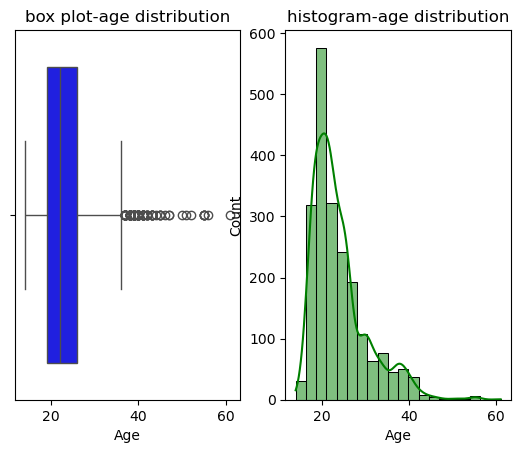

In [24]:
plt.subplot(1,2,1)
sn.boxplot(x="Age",data=df1,color="blue")
plt.title("box plot-age distribution")
plt.subplot(1,2,2)
sn.histplot(x="Age",bins=20,kde=True,color='green',data=df1)
plt.title("histogram-age distribution")
plt.show()

            NObeyesdad    Age
0  Insufficient_Weight  19.42
1        Normal_Weight  21.76
2       Obesity_Type_I  25.50
3      Obesity_Type_II  27.75
4     Obesity_Type_III  23.05
5   Overweight_Level_I  23.18
6  Overweight_Level_II  26.64


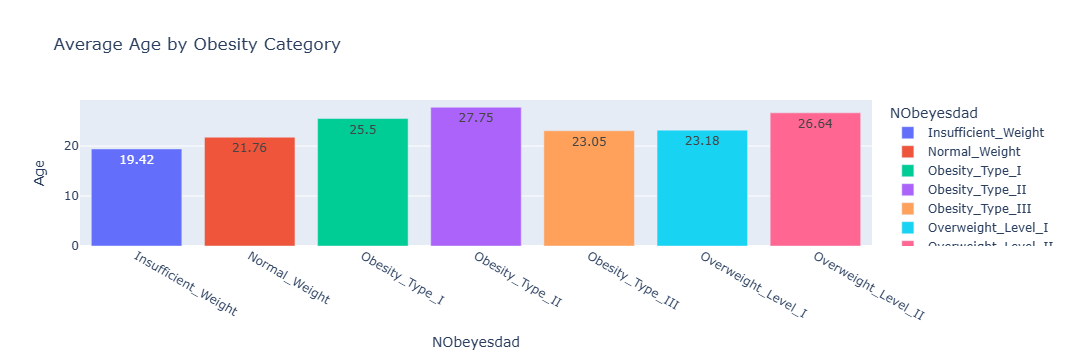

In [52]:
age_obesity = df1.groupby("NObeyesdad")["Age"].mean().round(2).reset_index()
print(age_obesity)
fig = px.bar(age_obesity,
             x="NObeyesdad",
             y="Age",
             color="NObeyesdad",
             text="Age",
             title="Average Age by Obesity Category")
fig.show()


#### Findings:The dataset shows that the majority of participants are close to 20 years old. Specifically, the average age of individuals in Obesity Category III is 23.05 years.

### 2.Gender and obesity

In [62]:
print("total number of male and female in the dataset:\n",df1["Gender"].value_counts())

total number of male and female in the dataset:
 Gender
Male      1052
Female    1035
Name: count, dtype: int64


             NObeyesdad  Gender  Count
0   Insufficient_Weight  Female    169
1   Insufficient_Weight    Male     98
2         Normal_Weight  Female    137
3         Normal_Weight    Male    145
4        Obesity_Type_I  Female    156
5        Obesity_Type_I    Male    195
6       Obesity_Type_II  Female      2
7       Obesity_Type_II    Male    295
8      Obesity_Type_III  Female    323
9      Obesity_Type_III    Male      1
10   Overweight_Level_I  Female    145
11   Overweight_Level_I    Male    131
12  Overweight_Level_II  Female    103
13  Overweight_Level_II    Male    187


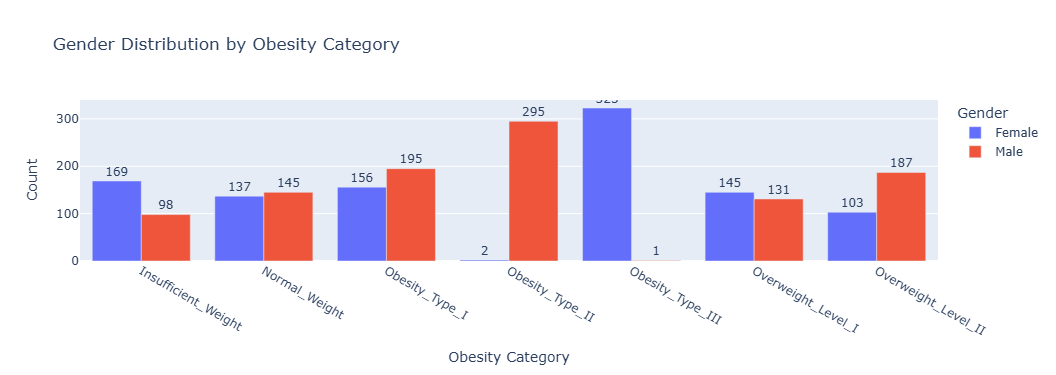

In [25]:

gender_obesity = df1.groupby(["NObeyesdad","Gender"]).size().reset_index(name="Count")
print(gender_obesity)

fig = px.bar(gender_obesity,
             x="NObeyesdad",
             y="Count",
             color="Gender",
             barmode="group",
             text="Count",
             title="Gender Distribution by Obesity Category")
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(xaxis_title="Obesity Category",
                  yaxis_title="Count",
                  legend_title="Gender")

fig.show()



#### Findings:The dataset has 1,052 males and 1,035 females, showing a balanced gender distribution.
#### Gender distribution varies across obesity categories, with some categories showing higher female counts (e.g., Obesity Type III).

#### Overall, obesity levels are spread across both genders, but patterns differ by category.

### 3.BMI and obesity

In [64]:
bmi_obesity=df1.groupby("NObeyesdad")["BMI"].mean().round(2)
print(bmi_obesity)

NObeyesdad
Insufficient_Weight    17.39
Normal_Weight          22.01
Obesity_Type_I         32.26
Obesity_Type_II        36.72
Obesity_Type_III       42.27
Overweight_Level_I     25.96
Overweight_Level_II    28.22
Name: BMI, dtype: float64


#### Findings:Average BMI of people having obesity problem is above 30

### 4.family history and obesity

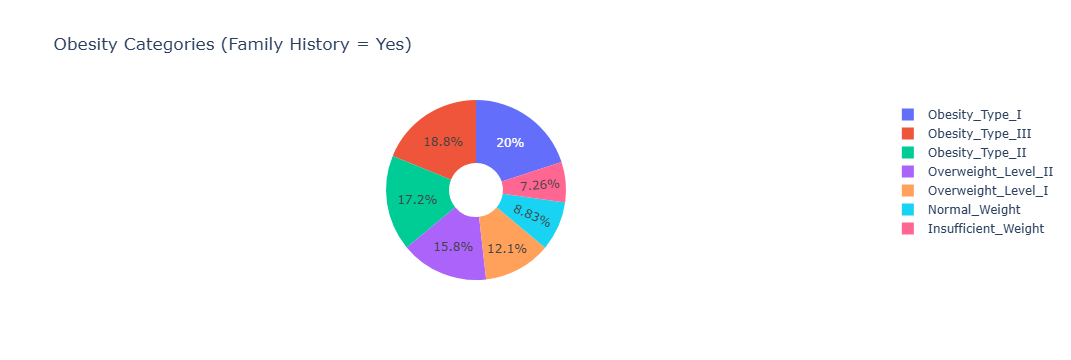

In [65]:

# Filter dataset for family history = Yes
fh_yes = df1[df1["family_history_with_overweight"] == "yes"]

# Count people in each obesity category
obesity_counts = fh_yes["NObeyesdad"].value_counts().reset_index()
obesity_counts.columns = ["NObeyesdad", "Count"]

# Pie chart
fig = px.pie(obesity_counts,
             names="NObeyesdad",
             values="Count",
             title="Obesity Categories (Family History = Yes)",
             hole=0.3)

fig.show()


#### Findings:Among individuals with a family history of overweight, the majority fall into obesity-related categories, with Obesity Type I (20%) and Insufficient Weight (18.8%) being the largest groups. This shows that family history strongly influences weight outcomes, but the impact varies across categories.

### 5.High calorie food and obesity


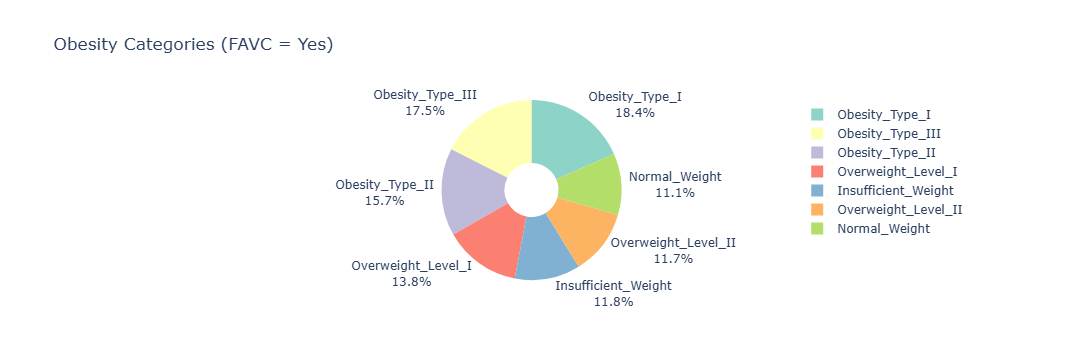

In [66]:
# Filter dataset for FAVC = Yes
favc_yes = df1[df1["FAVC"] == "yes"]

# Count people in each obesity category
obesity_counts = favc_yes["NObeyesdad"].value_counts().reset_index()
obesity_counts.columns = ["NObeyesdad", "Count"]

# Pie chart
fig = px.pie(obesity_counts,
             names="NObeyesdad",
             values="Count",
             title="Obesity Categories (FAVC = Yes)",
             hole=0.3,  # donut style
             color_discrete_sequence=px.colors.qualitative.Set3)

# Add percentage labels
fig.update_traces(textinfo="percent+label")

fig.show()

#### Findings:Frequent consumption of high‑calorie food (FAVC = Yes) is strongly associated with obesity, with Obesity Types I, II, and III together accounting for over half of the affected population.

### 6.vegitarians and obesity

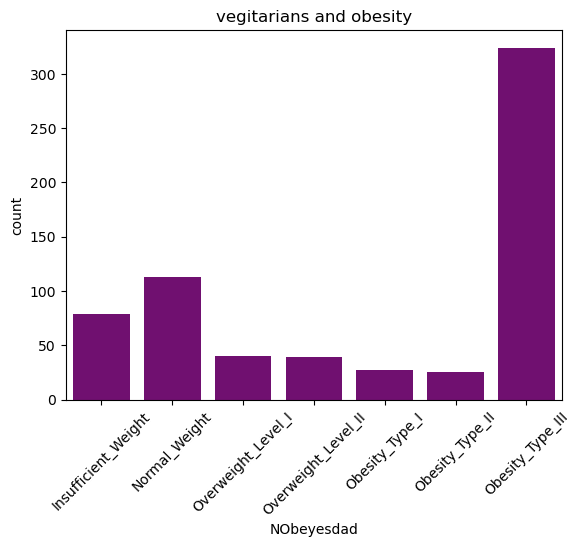

In [38]:
veg_group=df1[df1['FCVC']>=3]
order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]
veg_obesity=veg_group['NObeyesdad'].value_counts().reset_index()
sn.barplot(x="NObeyesdad",y="count",data=veg_obesity,order=order,color="purple")
plt.title("vegitarians and obesity")
plt.xticks(rotation=45)
plt.show()

#### finding:Vegetarian diet ≠ protection from obesity  
#### The data shows that even among vegetarians, severe obesity (Type III) is disproportionately high. This challenges the assumption that vegetarian diets automatically lead to healthier weight outcomes.
#### Polarized distribution  
#### There’s a sharp contrast: a large cluster in extreme obesity and a smaller cluster in normal/underweight. This polarization suggests lifestyle factors (like portion size, processed vegetarian foods, or sedentary habits) may play a bigger role than diet type alone.

#### 7.No.main meal and obesity

   NCP  count
0    3    693
1    2    149
2    1    131
3    4      1


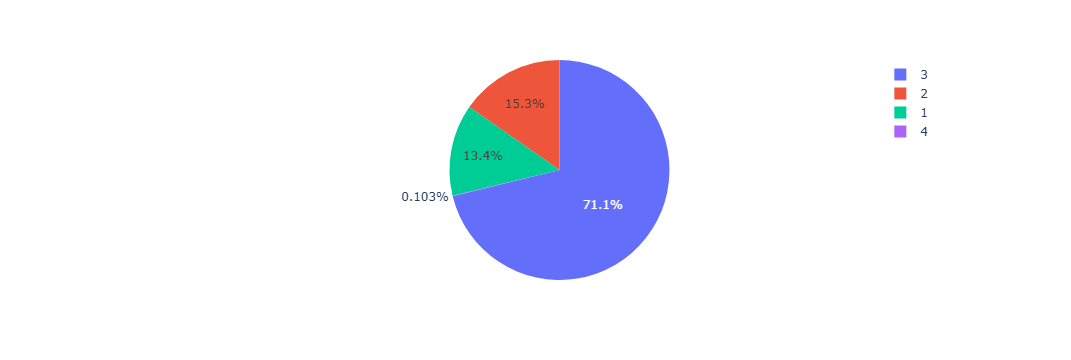

In [81]:
obesity_high=df1[df1["ObesityRisk"]=="High"]
no_meal=obesity_high["NCP"].value_counts().reset_index()
print(no_meal)
fig=px.pie(no_meal,names="NCP",values="count")
fig.show()

#### Findings:Among individuals with high obesity risk, the majority (71%) consume three main meals daily, indicating that meal frequency alone does not safeguard against obesity, while irregular patterns of one or two meals also show notable associations with risk

### 8.food b/w meals and obesity

In [85]:
print(df1["CAEC"].value_counts())

CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64


In [89]:
no_meals=df1.groupby(["ObesityRisk","CAEC"])["CAEC"].count()
print(no_meals)

ObesityRisk  CAEC      
High         Always          8
             Frequently      8
             Sometimes     956
             no              2
Low          Always         45
             Frequently    228
             Sometimes     805
             no             35
Name: CAEC, dtype: int64


#### finding:Most individuals, regardless of obesity risk, report eating food between meals ‘sometimes.’ Interestingly, frequent or always snacking is more common among low-risk individuals, suggesting that the type and quality of snacks may be more influential than snacking frequency itsel

### 9.smoking and obesity

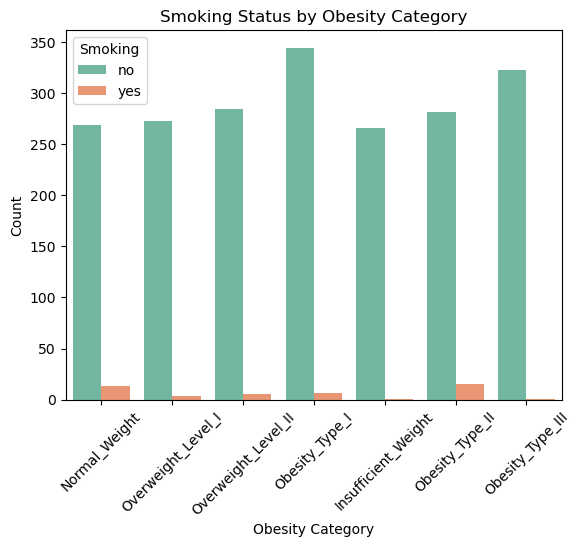

In [91]:
sn.countplot(x="NObeyesdad", hue="SMOKE", data=df1, palette="Set2")

plt.title("Smoking Status by Obesity Category")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Smoking")
plt.show()

#### Findings:The dataset shows that non‑smokers significantly outnumber smokers across all obesity categories. This indicates that smoking is relatively uncommon in the population studied, and obesity levels are more strongly influenced by other lifestyle factors rather than smoking status

### 10.water intake and obesity

C:\Users\layaj\AppData\Local\Temp\ipykernel_19756\2169330370.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




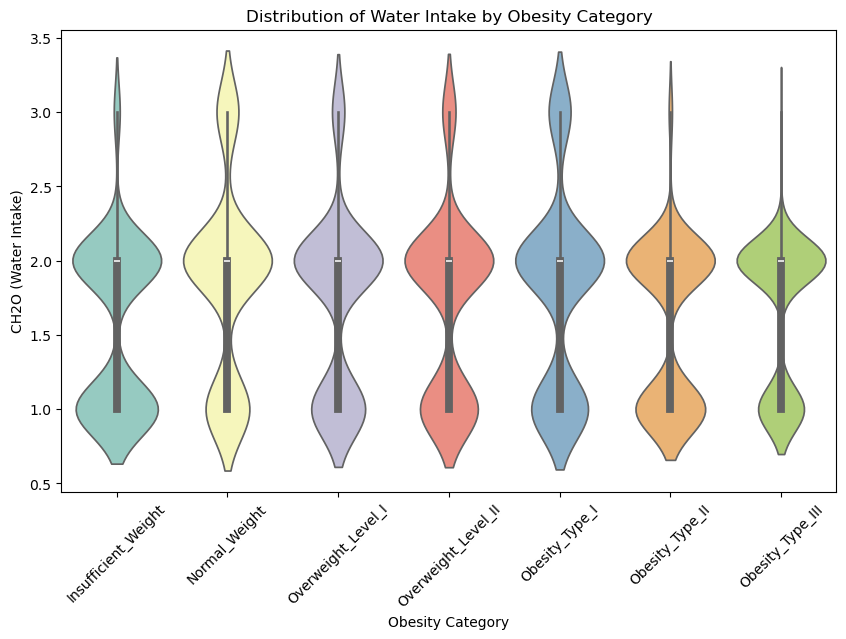

In [33]:
order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]
plt.figure(figsize=(10,6))
sn.violinplot(x="NObeyesdad", y="CH2O", data=df1,order=order, palette="Set3")

plt.title("Distribution of Water Intake by Obesity Category")
plt.xlabel("Obesity Category")
plt.ylabel("CH2O (Water Intake)")
plt.xticks(rotation=45)
plt.show()

#### Findings:Individuals with higher water intake (CH2O) tend to cluster in healthier categories such as Normal Weight and Insufficient Weight, while lower water intake values are more common among higher obesity categories (Obesity Types I–III). This suggests that adequate water consumption is associated with reduced obesity risk.

### 11.monitoring eating

In [94]:
print(df1["SCC"].value_counts())

SCC
no     1991
yes      96
Name: count, dtype: int64


#### Finding:The majority of people are not concerned about eating calories.

### 12.Physical activity and obesity

NObeyesdad
Insufficient_Weight    1.00
Normal_Weight          1.25
Obesity_Type_I         0.71
Obesity_Type_II        0.52
Obesity_Type_III       0.36
Overweight_Level_I     0.74
Overweight_Level_II    0.65
Name: FAF, dtype: float64


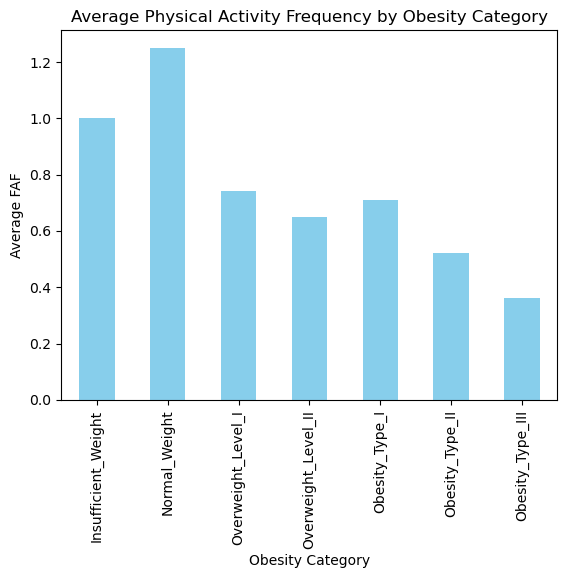

In [35]:
avg_faf = df1.groupby("NObeyesdad")["FAF"].mean().round(2)
print(avg_faf)

order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

# Reorder the Series before plotting
avg_faf = avg_faf.reindex(order)

avg_faf.plot(kind="bar", color="skyblue")
plt.title("Average Physical Activity Frequency by Obesity Category")
plt.ylabel("Average FAF")
plt.xlabel("Obesity Category")
plt.show()


#### Findings:More activity, less obesity; less activity, more obesity.
#### People with Normal_Weight and Insufficient_Weight show the highest average physical activity frequency (FAF), while those in Obesity_Type_III show the lowest FAF.

#### This strongly suggests that higher physical activity is associated with lower obesity risk, and as obesity severity increases, physical activity frequency tends to decline.

### 13.Screen time and obesity

In [32]:
screen_time=df1.groupby("NObeyesdad")["TUE"].mean().round()
print(screen_time)

NObeyesdad
Insufficient_Weight    1.0
Normal_Weight          1.0
Obesity_Type_I         0.0
Obesity_Type_II        0.0
Obesity_Type_III       0.0
Overweight_Level_I     0.0
Overweight_Level_II    0.0
Name: TUE, dtype: float64


#### Finding:Screen time doesn’t vary much by obesity level in your dataset — it’s consistently minimal, suggesting that screen time may not be a strong differentiator among these groups.

### 14.Alcohol consumption and obesity

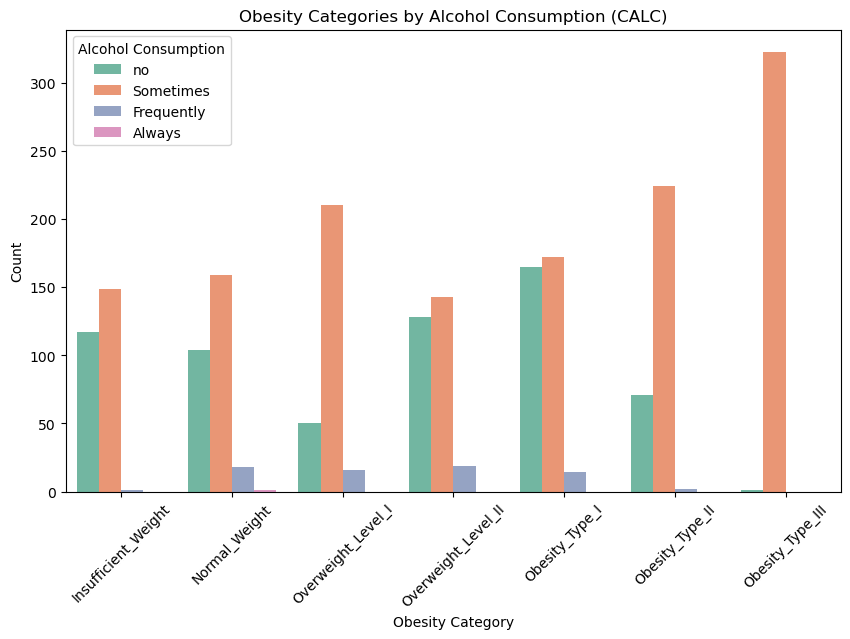

In [36]:
order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]
plt.figure(figsize=(10,6))
sn.countplot(x="NObeyesdad", hue="CALC", data=df1,order=order, palette="Set2")

plt.title("Obesity Categories by Alcohol Consumption (CALC)")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Alcohol Consumption")
plt.show()

#### Findings:Alcohol consumption is mostly occasional (“Sometimes”), with heavy drinking being rare and not strongly associated with obesity categories in this dataset.

### 15.method of transportation and obesity

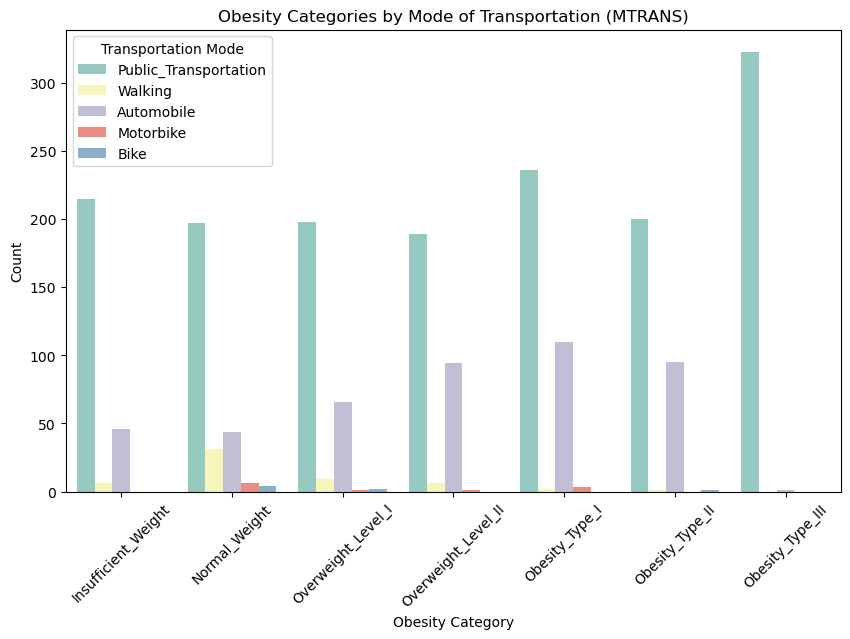

In [37]:
plt.figure(figsize=(10,6))
order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]
sn.countplot(x="NObeyesdad", hue="MTRANS", data=df1,order=order, palette="Set3")

plt.title("Obesity Categories by Mode of Transportation (MTRANS)")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Transportation Mode")
plt.show()

#### Findings:Public transportation dominates across all obesity categories — meaning people of every weight group rely on it the most. This suggests that mode of transport is more about accessibility and affordability than health-conscious choice.

#### Automobile users are the second largest group, and they show a stronger presence in higher obesity categories (Obesity Type I, II, III) compared to walking or biking. This hints at a possible link between sedentary travel habits and obesity risk.

## Insight Generation and Report- Obesity Dataset Analysis

#### 1.Youthful dataset: Most participants are ~20 years old; severe obesity (Type III) averages 23 years.


#### 2.Lifestyle drives obesity: High‑calorie food, low water intake, low physical activity are the strongest predictors.


#### 3.Family history matters: Overweight family background strongly increases obesity risk, especially in Type I.


#### 4.Habits outweigh labels: Vegetarian diets, snacking frequency, smoking, and alcohol show weaker links — lifestyle quality is more decisive.


#### 5.Sedentary patterns dominate: Automobile use and long technology hours align with higher obesity categories, reinforcing inactivity as a key risk factor



### Conclusion & Recommendations
#### Conclusion 

#### This dataset of 2,111 individuals highlights that obesity is shaped less by demographics (age, gender, diet labels) and more by lifestyle behaviors. Key drivers include high‑calorie food intake, low water consumption, reduced physical activity, and reliance on sedentary transport. Family history also plays a significant role, but its impact varies across categories. Overall, the findings emphasize that obesity is a multifactorial condition where daily habits outweigh simple dietary choices.

#### Recommendations


#### 🔵 Promote active lifestyles: Encourage regular physical activity .

 

#### 🔵 Encourage hydration: Adequate water intake should be emphasized as a protective factor against obesity.



#### 🔵 Improve diet quality: Focus on reducing high‑calorie food consumption and improving snack quality rather than eliminating snacking altogether.



#### 🔵 Rethink transport habits: Promote walking, biking, and public transport to counteract the dominance of automobile use and its sedentary impact.



#### 🔵 Target family risk groups: Provide tailored interventions for individuals with a family history of overweight, as they are more vulnerable to obesity.



#### 🔵 Challenge assumptions: Vegetarian diets alone do not guarantee healthy weight outcomes; portion control and lifestyle balance are critical.



#### 🔵 Raise awareness: Increase education on calorie awareness and lifestyle choices to empower individuals in managing weight risks.
